# 06 — Power Spectra Comparison

**Purpose:** Compare the two-point statistics of Agora test maps, DDPM-generated samples,
and Gaussian realisations.

This notebook computes and plots the angular auto- and cross-power spectra for the CIB
and tSZ channels:

1. **Auto-spectra** — Cℓ^{CIB} and Cℓ^{tSZ} for all three sample types, binned over
   300 < ℓ < 4000 in bins of Δℓ = 60.

2. **Cross-spectrum** — Cℓ^{CIB×tSZ} probing spatial correlation between dusty
   star-forming galaxies and hot gas traced by tSZ.

3. **Residuals** — (C_ℓ^{Agora} − C_ℓ^{DDPM}) / σ(C_ℓ^{Agora}) to quantify agreement
   within sample variance.

4. **Multi-frequency correlations** — cross-correlation coefficients between the 95, 150,
   and 857 GHz CIB channels (Appendix B).

**Inputs:**
- Test maps and DDPM samples: `data/low_pass/2mJy/*.npy`
- Gaussian baseline: `data/low_pass/2mJy/gaussian_cib_tsz_2mJy_lp.npy`
- ILC noise power spectra: `data/ilc/ilc_weights_residuals_agora_fg_model.npy`

**Outputs:** power spectrum comparison plots (Figure 4), multi-frequency correlation
plots (Figure 9).

**Key module functions:**
- `foregrounds_diffusion.flatmaps.map2cl`
- `foregrounds_diffusion.flatmaps.cl2map`
- `foregrounds_diffusion.preprocessing.renormalize_dm_maps`

**Paper reference:** §4.3 (Figure 4), Appendix B (Figure 9).

In [1]:
!pip install -e ~/cmb_foregrounds_diffusion/

Obtaining file:///home/apb86/cmb_foregrounds_diffusion
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for foregrounds_diffusion (pyproject.toml) ... done
  Created wheel for foregrounds_diffusion: filename=foregrounds_diffusion-0.1.0-0.editable-py3-none-any.whl size=4647 sha256=b76fc0f3b45428017f0c8c7bae3971ba9af0f18d749970923cd38d0628ec970e
  Stored in directory: /tmp/pip-ephem-wheel-cache-k7415x00/wheels/ad/05/47/d622ea03cc2c607997f65b7643dab9c4f27fa5f37d82097115
Successfully built foregrounds_diffusion
  Attempting uninstall: foregrounds_diffusion
    Found existing installation: foregrounds_diffusion 0.1.0
    Uninstalling foregrounds_diffusion-0.1.0:
      Successfully uninstalled foregrounds_diffusion-0.1.0

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip insta

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from foregrounds_diffusion.flatmaps import map2cl
from foregrounds_diffusion.preprocessing import renormalize_dm_maps

PTSRC = 2
flatskymapparams = [256, 256, 1.41, 1.41]   # [nx, ny, dx_arcmin, dy_arcmin]
LMIN, LMAX, LBIN = 300, 4000, 60

PROJECT_ROOT = Path("/home/apb86/cmb_foregrounds_diffusion")
PATCHES_DIR = Path(f"data/low_pass/{PTSRC}mJy")


In [3]:
cib_maps    = np.load(PATCHES_DIR / f"CIB_map_150GHz_256_st6_minmax_{PTSRC}mJy_zero_lp.npy")
tsz_maps    = np.load(PATCHES_DIR / f"tSZ3_map_150GHz_256_st6_minmax_{PTSRC}mJy_norm_lp.npy")
#ddpm_raw    = np.load(PATCHES_DIR / f"new_samples_cib_tsz_{PTSRC}mJy_lp.npy")
gauss_maps  = np.load(PATCHES_DIR / f"gaussian_cib_tsz_{PTSRC}mJy_lp.npy")

# DDPM samples are (N, 2, H, W) channels-first; Agora/Gaussian are (N, H, W, 1)
#ddpm_cib = ddpm_raw[:, 0]   # (N, H, W)
#ddpm_tsz = ddpm_raw[:, 1]

agora_cib  = cib_maps[:, :, :, 0]
agora_tsz  = tsz_maps[:, :, :, 0]

# gauss_maps shape depends on generation; handle both (N, 2, H, W) and (N, H, W, 2)
if gauss_maps.ndim == 4 and gauss_maps.shape[1] == 2:
    gauss_cib = gauss_maps[:, 0]
    gauss_tsz = gauss_maps[:, 1]
else:
    gauss_cib = gauss_maps[:, :, :, 0]
    gauss_tsz = gauss_maps[:, :, :, 1]

#N = min(len(agora_cib), len(ddpm_cib), len(gauss_cib))
N = min(len(agora_cib), len(gauss_cib))
print(f"Using {N} maps from each source for power spectrum estimation")


Using 674 maps from each source for power spectrum estimation


In [8]:
def mean_cls(maps_nhw, mapparams, lmin, lmax, binsize):
    """Compute mean auto-power spectrum over N maps, returning (el, mean_cl, std_cl)."""
    cls = []
    for m in maps_nhw:
        el, cl = map2cl(mapparams, m, binsize=binsize, minbin=lmin, maxbin=lmax)
        cls.append(cl)
    cls = np.array(cls)
    return el, cls.mean(axis=0), cls.std(axis=0)

def mean_cross_cls(maps1, maps2, mapparams, lmin, lmax, binsize):
    cls = []
    for m1, m2 in zip(maps1, maps2):
        el, cl = map2cl(mapparams, m1, m2, binsize=binsize, minbin=lmin, maxbin=lmax)
        cls.append(cl)
    cls = np.array(cls)
    return el, cls.mean(axis=0), cls.std(axis=0)

el, cl_cib_agora,  cl_cib_agora_err  = mean_cls(agora_cib[:N],  flatskymapparams, LMIN, LMAX, LBIN)
#_,  cl_cib_ddpm,   cl_cib_ddpm_err   = mean_cls(ddpm_cib[:N],   flatskymapparams, LMIN, LMAX, LBIN)
_,  cl_cib_gauss,  cl_cib_gauss_err  = mean_cls(gauss_cib[:N],  flatskymapparams, LMIN, LMAX, LBIN)

_,  cl_tsz_agora,  cl_tsz_agora_err  = mean_cls(agora_tsz[:N],  flatskymapparams, LMIN, LMAX, LBIN)
#_,  cl_tsz_ddpm,   cl_tsz_ddpm_err   = mean_cls(ddpm_tsz[:N],   flatskymapparams, LMIN, LMAX, LBIN)
_,  cl_tsz_gauss,  cl_tsz_gauss_err  = mean_cls(gauss_tsz[:N],  flatskymapparams, LMIN, LMAX, LBIN)

_,  cl_cross_agora,  _  = mean_cross_cls(agora_cib[:N], agora_tsz[:N], flatskymapparams, LMIN, LMAX, LBIN)
#_,  cl_cross_ddpm,   _  = mean_cross_cls(ddpm_cib[:N],  ddpm_tsz[:N],  flatskymapparams, LMIN, LMAX, LBIN)
_,  cl_cross_gauss,  _  = mean_cross_cls(gauss_cib[:N], gauss_tsz[:N], flatskymapparams, LMIN, LMAX, LBIN)


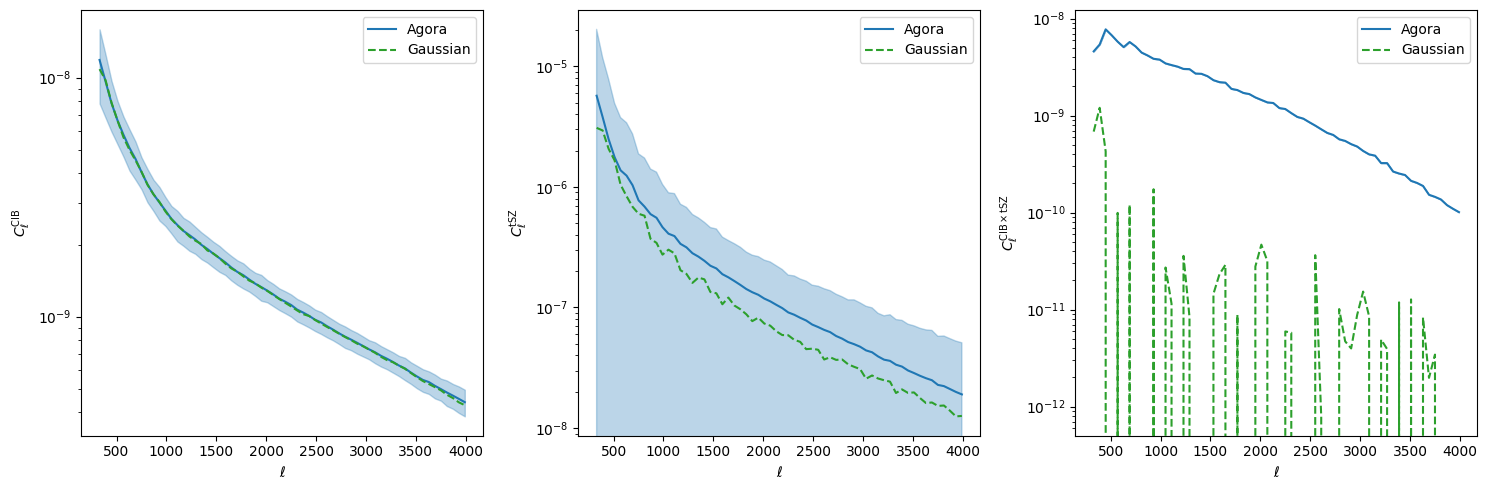

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

"""
for ax, cl_a, err_a, cl_d, err_d, cl_g, title in zip(
    axes,
    [cl_cib_agora,   cl_tsz_agora,   cl_cross_agora],
    [cl_cib_agora_err, cl_tsz_agora_err, np.zeros_like(cl_cross_agora)],
    [cl_cib_ddpm,    cl_tsz_ddpm,    cl_cross_ddpm],
    [cl_cib_ddpm_err,  cl_tsz_ddpm_err,  np.zeros_like(cl_cross_ddpm)],
    [cl_cib_gauss,   cl_tsz_gauss,   cl_cross_gauss],
    [r"$C_\ell^{\rm CIB}$", r"$C_\ell^{\rm tSZ}$", r"$C_\ell^{\rm CIB \times tSZ}$"],
):
"""
for ax, cl_a, err_a, cl_g, title in zip(
    axes,
    [cl_cib_agora,   cl_tsz_agora,   cl_cross_agora],
    [cl_cib_agora_err, cl_tsz_agora_err, np.zeros_like(cl_cross_agora)],
    [cl_cib_gauss,   cl_tsz_gauss,   cl_cross_gauss],
    [r"$C_\ell^{\rm CIB}$", r"$C_\ell^{\rm tSZ}$", r"$C_\ell^{\rm CIB \times tSZ}$"],
):
    ax.fill_between(el, cl_a - err_a, cl_a + err_a, alpha=0.3, color="C0")
    ax.plot(el, cl_a, label="Agora", color="C0")
    ax.plot(el, cl_g, label="Gaussian", color="C2", linestyle="--")
    ax.set_xlabel(r"$\ell$");  ax.set_ylabel(title);  ax.legend()
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

In [6]:
# Fractional residuals normalised by Agora sample variance
"""
resid_cib = (cl_cib_agora - cl_cib_ddpm) / (cl_cib_agora_err + 1e-30)
resid_tsz = (cl_tsz_agora - cl_tsz_ddpm) / (cl_tsz_agora_err + 1e-30)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.plot(el, resid_cib)
ax1.set_xlabel(r"$\ell$");  ax1.set_ylabel(r"$(C_\ell^{\rm Agora} - C_\ell^{\rm DDPM}) / \sigma$")
ax1.set_title("CIB residuals")

ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.plot(el, resid_tsz)
ax2.set_xlabel(r"$\ell$");  ax2.set_title("tSZ residuals")
plt.tight_layout();  plt.show()
"""


'\nresid_cib = (cl_cib_agora - cl_cib_ddpm) / (cl_cib_agora_err + 1e-30)\nresid_tsz = (cl_tsz_agora - cl_tsz_ddpm) / (cl_tsz_agora_err + 1e-30)\n\nfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))\nax1.axhline(0, color="k", lw=0.8, ls="--")\nax1.plot(el, resid_cib)\nax1.set_xlabel(r"$\\ell$");  ax1.set_ylabel(r"$(C_\\ell^{\rm Agora} - C_\\ell^{\rm DDPM}) / \\sigma$")\nax1.set_title("CIB residuals")\n\nax2.axhline(0, color="k", lw=0.8, ls="--")\nax2.plot(el, resid_tsz)\nax2.set_xlabel(r"$\\ell$");  ax2.set_title("tSZ residuals")\nplt.tight_layout();  plt.show()\n'